In [1]:
from google.colab import files

uploaded = files.upload()

# After uploading, you need to get the filename
# The 'uploaded' variable is a dictionary where keys are the filenames
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  file_name = fn # Store the filename for later use


Saving main.csv to main.csv
User uploaded file "main.csv" with length 699857 bytes


In [3]:
import pandas as pd

import pandas as pd

# Load the uploaded file into a DataFrame
# Use 'main.csv' as the file name
df = pd.read_csv('main.csv')

# Print the first 5 rows to verify it loaded correctly
print(df.head())



   StudentId  CGPA  SSC_Marks  HSC_Marks  backlogs Internship  Projects  \
0          1   7.5         79         61         2         No         1   
1          2   8.9         82         78         0        Yes         0   
2          3   7.3         80         79         2        Yes         1   
3          4   7.5         80         81         0        Yes         1   
4          5   8.3         88         74         0        Yes         1   

   MiniProjects  CertificationsCount Hackathon  AptitudeTestScore  \
0             1                    1        No              65.66   
1             2                    3       Yes              90.03   
2             2                    2        No              73.13   
3             2                    1       Yes              76.89   
4             2                    2       Yes              82.60   

   TechnicalSkillsScore  CommunicationSkillRating  LeadershipSkill  \
0                   3.8                       4.4              6

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load and Preprocess the Data

# Load your dataset from the uploaded file 'main.csv'
df = pd.read_csv('main.csv')

# Separate features (X) and target (y)
# Drop 'StudentId' as it is not a predictive feature
X = df.drop(['StudentId', 'PlacementStatus'], axis=1)
y = df['PlacementStatus']

# Encode categorical features and the target variable
le = LabelEncoder()
for col in ['Internship', 'Hackathon']:
    if col in X.columns:
        X[col] = le.fit_transform(X[col])

# 'Placed' will become 1, 'NotPlaced' will become 0
y = le.fit_transform(y)

# Step 2: Split the Data into Training and Testing Sets

# Split the data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the Machine Learning Model

# Initialize the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Step 4: Make Predictions and Evaluate the Model

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 93.55%


Model Accuracy: 93.55%


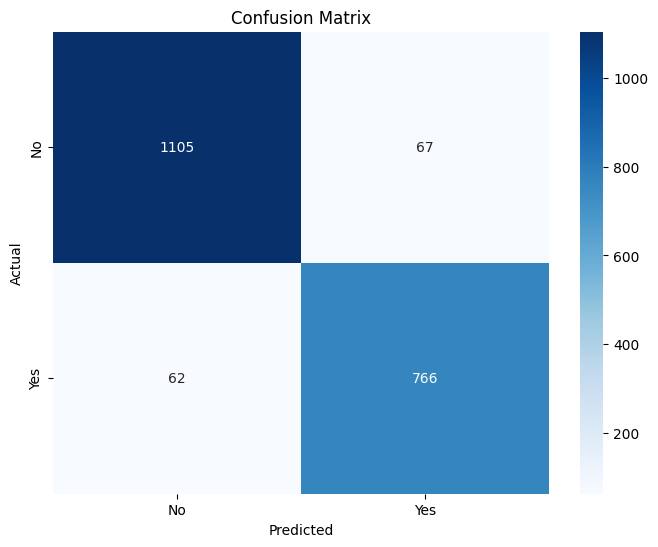

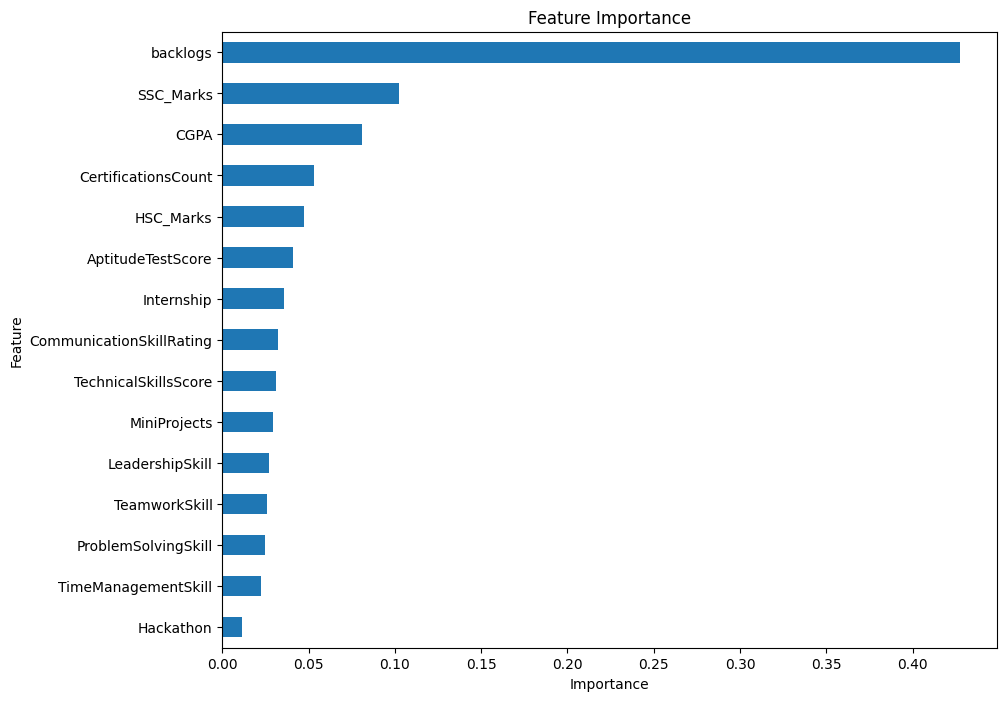

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load and Preprocess the Data
# Old line
df = pd.read_csv('main.csv') 

X = df.drop(['StudentId', 'PlacementStatus'], axis=1)
y = df['PlacementStatus']

le = LabelEncoder()
for col in ['Internship', 'Hackathon']:
    if col in X.columns:
        X[col] = le.fit_transform(X[col])

# Store the class names ('NotPlaced', 'Placed') before transforming y
class_names = le.classes_
y = le.fit_transform(y)


# Step 2: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 4: Evaluate and Print Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


# Step 5: Plotting the Graphs

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# --- Plot 2: Feature Importance ---
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
feature_importances.nlargest(15).sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

